## Imports and env variables

In [5]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

## Testing

In [3]:
model = init_chat_model(model = 'groq:llama-3.1-8b-instant')
result = model.invoke("Write a one line joke on penguins")
result

AIMessage(content='Why did the penguin take his credit card to the Antarctic? Because he wanted to freeze his assets.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 43, 'total_tokens': 65, 'completion_time': 0.018371769, 'completion_tokens_details': None, 'prompt_time': 0.002517013, 'prompt_tokens_details': None, 'queue_time': 0.050016617, 'total_time': 0.020888782}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f5511-eceb-7691-babf-cf4a6e5f60d6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 22, 'total_tokens': 65})

## Simple QA chat graph

In [6]:
class SimpleQA(TypedDict):
    question: str
    answer: str

# function to create a simple QA workflow
def simpleqa(state: SimpleQA) -> SimpleQA:
    question = state['question']
    answer = model.invoke(question).content
    state['answer'] = answer
    return state

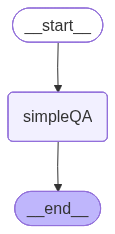

In [10]:
# Create a graph to represent the workflow
graph = StateGraph(SimpleQA)

# add nodes to the graph
graph.add_node("simpleQA",simpleqa)

# add edges to the graph
graph.add_edge(START, "simpleQA")
graph.add_edge("simpleQA", END)

# compile the graph into a workflow
workflow = graph.compile()

## Visualizing the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())


## Graph usage

In [ ]:
initial_state = {"question": "What is the hottest planet in our Solar System?"}
final_state = workflow.invoke(initial_state)

print(initial_state)
print('--'*40)
print(final_state['answer'])

{'question': 'What is the hottest planet in our Solar System?'}
--------------------------------------------------------------------------------
{'question': 'What is the hottest planet in our Solar System?', 'answer': "The hottest planet in our Solar System is Venus. It has a thick atmosphere composed mainly of carbon dioxide, which creates a strong greenhouse effect. This effect traps heat from the sun and causes the planet's surface temperature to reach as high as 462°C (863°F)."}


In [14]:
print(final_state['answer'])

The hottest planet in our Solar System is Venus. It has a thick atmosphere composed mainly of carbon dioxide, which creates a strong greenhouse effect. This effect traps heat from the sun and causes the planet's surface temperature to reach as high as 462°C (863°F).
